<a href="https://colab.research.google.com/github/Likky1510/TextVectorization/blob/main/Textvectorization_ipyb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Understanding the Music & Text Analysis Workflow

If you are new to this, here is a breakdown of every concept we used, explained simply.

### 1. Natural Language Processing (NLP)
NLP is how we teach computers to understand human language. Since computers only understand numbers, we have to follow a specific 'cleaning' process.

### 2. The Preprocessing Pipeline
Before analyzing text, we have to tidy it up:
*   **Lowercasing**: 'Lord' and 'lord' should be the same thing to a computer.
*   **Tokenization**: This is like cutting a sentence into individual pieces (words or 'tokens').
*   **Stemming**: We chop off the ends of words to get to the 'root'. For example, *darling*, *darlings*, and *darled* all become **'darl'**. This helps the computer realize they are the same core idea.

### 3. Bag of Words & Bigrams
*   **Count Vectorization**: We simply count how many times each word appears. If 'darl' appears 9 times, that word is a 'feature' of the song.
*   **Bigrams**: Instead of looking at one word, we look at pairs (e.g., 'oh lord', 'near me'). This helps capture a bit more meaning than single words alone.

### 4. Embeddings (The 'BERT' Model)
This is the most advanced part. **BERT** is a pre-trained AI that has read millions of books.
*   When we give it a sentence, it turns it into a list of 768 numbers (a **Vector**).
*   Unlike simple counting, BERT understands **context**. It knows that 'bank' (river) and 'bank' (money) are different because of the numbers it assigns.

### 5. Cosine Similarity (The 'Matchmaker')
Once we have these lists of numbers (vectors) from BERT, we use math to compare them.
*   Imagine two arrows pointing in space. If the arrows point in the same direction, they are 'similar'.
*   We used this to compare your query *'feeling of missing someone'* against the lyrics. The math found that *'Be near me, darling'* was the closest 'arrow' in terms of meaning.

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### **Text Preprocessing: Standardization, Tokenization, and Stemming**

First, let's install the `nltk` library and download the necessary data for tokenization and stemming.

In [ ]:
# Re-defining the input lyrics data
lyrics_data = """Oh lord
I'd like to know where she is now
If she thinks about me or not
Oh not, Oh lord
I wanna give her all my love
My life, my heart
And please her

I wonder if I'm right?
Or must I try to forget her?

Be near me, darling
I miss you darling
Oh bring me, darling
Your sweet kiss, darling

I thought you were happy with me
But I think I made a mistake
Thinking about it
Darling, am I right or wrong?

Be near me, darling
I miss you darling
Oh bring me, darling
Your sweet kiss, darling

Oh jah! Oh jah!
I'd like to be near her
Oh jah! Oh jah!
I miss and love her"""

In [ ]:
!pip install -qqq nltk
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# Initialize the stemmer
stemmer = PorterStemmer()

def preprocess_text(text):
    # 1. Standardization (lowercase)
    text = text.lower()
    # 2. Tokenization
    tokens = word_tokenize(text)
    # 1. Standardization (stemming)
    stemmed_tokens = [stemmer.stem(token) for token in tokens]
    return " ".join(stemmed_tokens)

# Apply preprocessing to the lyrics_data
processed_lyrics = preprocess_text(lyrics_data)

print("Original Lyrics (excerpt):", lyrics_data[:200], "...")
print("\nProcessed Lyrics (excerpt):", processed_lyrics[:200], "...")

Original Lyrics (excerpt): Oh lord
I'd like to know where she is now
If she thinks about me or not
Oh not, Oh lord
I wanna give her all my love
My life, my heart
And please her

I wonder if I'm right?
Or must I try to forget he ...

Processed Lyrics (excerpt): oh lord i 'd like to know where she is now if she think about me or not oh not , oh lord i wan na give her all my love my life , my heart and pleas her i wonder if i 'm right ? or must i tri to forget ...


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### **Multi-model Encoding for Text Vectorization**

Now, for multi-model encoding, we'll use a pre-trained transformer model from the `transformers` library. This will handle tokenization, indexing, and provide context-aware numerical representations (embeddings) of the text. We'll use a small BERT model for this demonstration.

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch

# Load pre-trained tokenizer and model (e.g., 'bert-base-uncased')
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
model = AutoModel.from_pretrained('bert-base-uncased')

# Encode the processed lyrics
# This step includes tokenization and indexing (converting words to model-specific IDs)
inputs = tokenizer(processed_lyrics, return_tensors='pt', truncation=True, padding=True)

# Perform multi-model encoding to get embeddings
with torch.no_grad():
    outputs = model(**inputs)

# The last_hidden_state contains the embeddings for each token
# We can take the embedding of the [CLS] token (first token) as a sentence embedding
lyrics_embedding = outputs.last_hidden_state[:, 0, :].squeeze()

print("Shape of the encoded lyrics embedding:", lyrics_embedding.shape)
print("Sample of the encoded lyrics embedding (first 10 values):", lyrics_embedding[:10])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Shape of the encoded lyrics embedding: torch.Size([768])
Sample of the encoded lyrics embedding (first 10 values): tensor([-0.4036, -0.1538,  0.2051, -0.1186, -0.7964, -0.1476,  0.5132,  0.4553,
        -0.2896, -0.3863])


### **Detailed Tokenization and Performance Analysis**

To understand how the model 'sees' the text, let's look at the subword tokenization and measure the execution time of the transformer forward pass.

In [ ]:
import time

# 1. Performance Measurement
start_time = time.time()
with torch.no_grad():
    outputs = model(**inputs)
end_time = time.time()

inference_time = end_time - start_time

# 2. Tokenization Detail
# Get the tokens (strings) from the input IDs
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
input_ids = inputs['input_ids'][0].tolist()

# Create a mapping for visualization
token_mapping = pd.DataFrame({
    'Token': tokens,
    'ID': input_ids
})

print(f"Inference Time (Forward Pass): {inference_time:.4f} seconds")
print(f"Total Tokens (including special [CLS]/[SEP]): {len(tokens)}")

print("\nFirst 20 Tokens and their IDs:")
display(token_mapping.head(20))

Inference Time (Forward Pass): 0.6394 seconds
Total Tokens (including special [CLS]/[SEP]): 162

First 20 Tokens and their IDs:


,Token,ID
0,[CLS],101
1,oh,2821
2,lord,2935
3,i,1045
4,',1005
5,d,1040
6,like,2066
7,to,2000
8,know,2113
9,where,2073


### **Analysis Notes**

*   **Tokenization**: BERT uses **WordPiece tokenization**. You'll notice some words are split into subwords (often indicated by `##`), and special tokens like `[CLS]` (start of sequence) and `[SEP]` (end of sequence) are added automatically.
*   **Performance**: The inference time reflects how long the 12-layer transformer takes to process the sequence and output the hidden states. On a standard Colab CPU/GPU, this is typically very fast for a single sentence.

### **Bigram Language Model Analysis**

Now, let's explore the text structure using a **Bigram Model**. A bigram is a sequence of two adjacent elements from a string of tokens. We will identify the most frequent pairs of words in the lyrics.

In [ ]:
from nltk import bigrams
from collections import Counter

# 1. Generate Bigrams from the processed lyrics tokens
# Note: using the tokens variable generated earlier in cell 7ae55190 before stemming if preferred,
# but here we use the stemmed tokens for consistent pattern matching.
lyrics_tokens = word_tokenize(processed_lyrics)
bigram_list = list(bigrams(lyrics_tokens))

# 2. Calculate Frequency Distribution
bigram_counts = Counter(bigram_list)

# 3. Create a DataFrame for visualization
bigram_df = pd.DataFrame(bigram_counts.most_common(15), columns=['Bigram', 'Frequency'])

# Format bigram column for better display
bigram_df['Bigram'] = bigram_df['Bigram'].apply(lambda x: f"{x[0]} {x[1]}")

print("Total Bigrams generated:", len(bigram_list))
print("\nTop 15 Most Frequent Bigrams:")
display(bigram_df)

Total Bigrams generated: 140

Top 15 Most Frequent Bigrams:


,Bigram,Frequency
0,", darl",6
1,"me ,",4
2,oh jah,4
3,jah !,4
4,be near,3
5,darl i,3
6,i miss,3
7,darl oh,3
8,oh lord,2
9,lord i,2


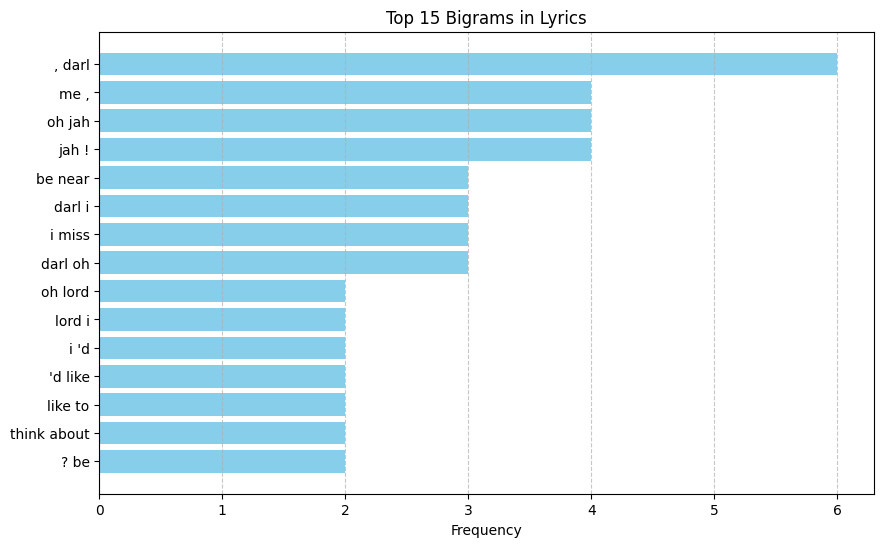

In [ ]:
# Visualize the Bigram frequencies
plt.figure(figsize=(10, 6))
plt.barh(bigram_df['Bigram'][::-1], bigram_df['Frequency'][::-1], color='skyblue')
plt.xlabel('Frequency')
plt.title('Top 15 Bigrams in Lyrics')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### **Bigram Frequency Table**

Below is the tabular summary of the most frequent word pairs (bigrams) found in the lyrics.

In [ ]:
# Displaying the top 15 bigrams in a table format
display(bigram_df.reset_index(drop=True))

,Bigram,Frequency
0,", darl",6
1,"me ,",4
2,oh jah,4
3,jah !,4
4,be near,3
5,darl i,3
6,i miss,3
7,darl oh,3
8,oh lord,2
9,lord i,2


### **Count Vectorization (Bag of Words)**

To complement the BERT embeddings, we'll use `CountVectorizer` from `scikit-learn`. This converts the text into a matrix of token counts, representing the lyrics as a numerical feature vector based on word frequency.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize the CountVectorizer
vectorizer = CountVectorizer()

# Fit and transform the processed lyrics
# We wrap [processed_lyrics] in a list because the vectorizer expects an iterable of strings
vector_sparse = vectorizer.fit_transform([processed_lyrics])

# Convert to a dense array for easier viewing
vector_dense = vector_sparse.toarray()

# Get the feature names (the vocabulary)
vocab = vectorizer.get_feature_names_out()

# Create a DataFrame to visualize the vectorization
vector_df = pd.DataFrame(vector_dense, columns=vocab)

print("Vocabulary Size:", len(vocab))
print("Vector Shape:", vector_dense.shape)

print("\nFirst 10 non-zero counts in the vector:")
display(vector_df.loc[:, (vector_df != 0).any(axis=0)].head())

Vocabulary Size: 51
Vector Shape: (1, 51)

First 10 non-zero counts in the vector:


,about,all,am,and,be,bring,but,darl,forget,give,...,to,tri,wan,were,where,with,wonder,wrong,you,your
0,2,1,1,2,3,2,1,9,1,1,...,3,1,1,1,1,1,1,1,3,2


### **Prediction Perspective: Semantic Similarity Ranking**

In a real-world scenario, you might want to predict which parts of a text are most relevant to a specific theme. We can use **Cosine Similarity** on our BERT embeddings to rank lines of the lyrics based on their semantic proximity to a target query.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# 1. Define segments of the lyrics for comparison
segments = [
    "I wanna give her all my love",
    "Be near me, darling",
    "I thought you were happy with me",
    "Oh jah! Oh jah!"
]

# 2. Define a 'Target Query' to predict relevance against
target_query = "feeling of missing someone or love"

# 3. Encode the segments and the query
def encode_text(text_list):
    inputs = tokenizer(text_list, return_tensors='pt', truncation=True, padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state[:, 0, :]

segment_embeddings = encode_text(segments)
query_embedding = encode_text([target_query])

# 4. Calculate similarities
similarities = cosine_similarity(query_embedding, segment_embeddings).flatten()

# 5. Create a ranked view
prediction_df = pd.DataFrame({
    'Lyric Segment': segments,
    'Similarity Score': similarities
}).sort_values(by='Similarity Score', ascending=False)

print(f"Ranking segments by relevance to: '{target_query}'")
display(prediction_df)

Ranking segments by relevance to: 'feeling of missing someone or love'


,Lyric Segment,Similarity Score
1,"Be near me, darling",0.798067
0,I wanna give her all my love,0.786646
2,I thought you were happy with me,0.785547
3,Oh jah! Oh jah!,0.755311


### **Visualizing the Embeddings (Vectors)**

Each lyric segment is converted into a vector of 768 numbers. We can visualize the first few dimensions of these vectors as a heatmap to see how the model differentiates between different lines of text.

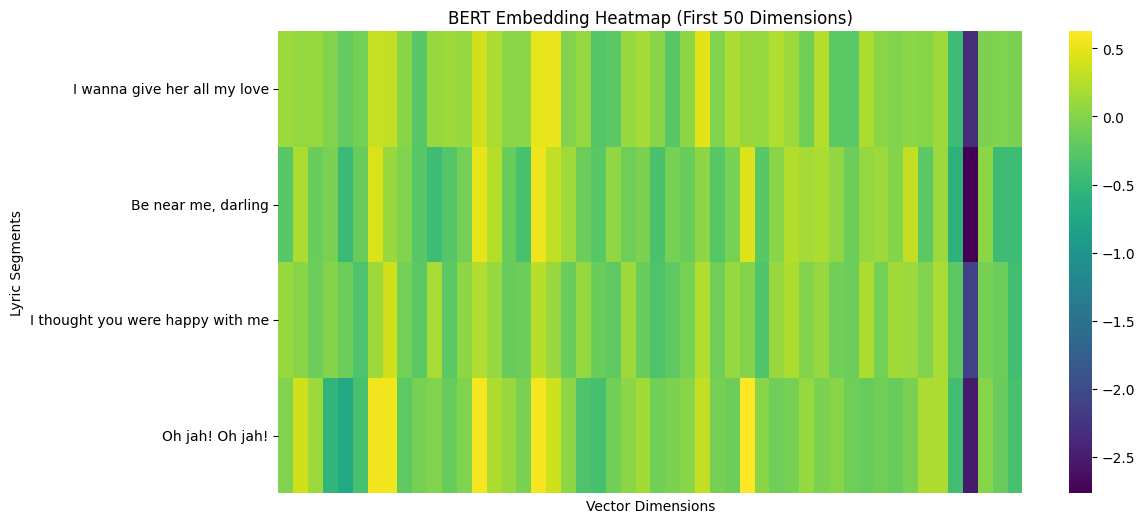

In [26]:
import seaborn as sns

# Convert embeddings to a numpy array for plotting
# We'll look at the first 50 dimensions to keep the plot readable
embedding_array = segment_embeddings.numpy()[:, :50]

plt.figure(figsize=(12, 6))
sns.heatmap(embedding_array, annot=False, cmap='viridis',
            yticklabels=segments, xticklabels=False)

plt.title('BERT Embedding Heatmap (First 50 Dimensions)')
plt.xlabel('Vector Dimensions')
plt.ylabel('Lyric Segments')
plt.show()